<h1>Coding Session #3 - Convolutional Neural Network</h1>

Führen Sie folgende Zelle aus, um alle benötigten Bibliotheken zu installieren:

In [ ]:
!pip install -r requirements.txt

## Ziel

In dieser Coding Session soll ein Faltungsnetz (Convolutional Neural Network - CNN) implementiert und trainiert werden. CCNs sind besonders effizient für die Bild- oder Videoverarbeitung. Da es sich bei Bildern um hochdimensionale Inputs handelt, sind Fully Connected (FC) Layer ungeeignet.

## 1 Convolutional Layer

Um ein RGB-Bild mit $1,920\times 1,080$ Pixeln zu repräsentieren, bräuchte man einen FC Layer mit 6.2 Mio. Neuronen:

<img src="images/curse_of_dimensionality.png" width="600px"></img>

Hier schafft das CNN Abhilfe. Dieses nutzt Convolutional Layer. Jeder Convolutional Layer hat eine bestimmte Anzahl an Kerneln, mit denen Faltungsoperationen auf den Input angewendet werden. Dafür slidet der Kernel Spalte für Spalte und Zeile für Zeile über das Input-Bild. An jeder Stelle werden die Pixel der Region des Inputbildes $X$ elementweise mit den Gewichtungen des Kernels $K$ multipliziert und anschließend die Summe der Produkte gebildet, um den Output an der Stelle $Y[m, n]$ zu erhalten. 

<img src="images/convolution001.png" width="600px"></img>

Mit Hilfe von Faltungen lassen sich Merkmale (Features) wie Ecken oder Kanten im Bild erkennen. Die Gewichtungen der Kernels sind lernbar. Somit kann das neuronale Netz daraufhin optimiert werden, aussagekräftige Features für den Input zu extrahieren.

Folgendes Beispiel visualisiert eine Faltung mit einem Kernel zur Detektion von vertikalen Kanten:

<img src="images/conv_animation.gif" width="600px"></img>

In [ ]:
from data import CornersAndEdgesDataset
import visualization as vis


ds = CornersAndEdgesDataset(num_samples=1000, image_size=256)


labels_txt = [ds.LABELS[label] for label in ds.labels]

vis.plot_images(ds.images, labels_txt)

> <span style="color:#00A1E3">**Aufgabe 1 - Convolutional Layer**</span>
> 1. Erstellen Sie eine Klasse `ConvLayer`, welche von `Module` ableitet.
> 2. Erstellen Sie den Konstruktor (`def __init__(self, in_channels, out_channels, kernel_size)`)
>       - Der Parameter `in_channels` steht für die Anzahl der Input-Kanäle des Layers. Bei einem RGB-Bild wären dies bspw. 3 Kanäle.
>       - Der Parameter `out_channels` steht für die Anzahl der Output-Kanäle des Layers. 
>       - Initialisieren Sie die Gewichtungen der 

In [1]:
import numpy as np
from model import Module

class ConvLayer(Module):
    def __init__(self, in_channels:int, out_channels:int, kernel_size:int):
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        # He initialization: normal distribution with mean 0 and variance 2/fan_in
        fan_in = in_channels * kernel_size * kernel_size
        self.kernels = np.random.randn(out_channels, in_channels, kernel_size, kernel_size) * np.sqrt(2.0 / fan_in)
    
    def forward(self, input:np.ndarray):
        self.input = input  # save input for backward pass
        batch_size, _, height, width = input.shape
        output_height = height - self.kernel_size + 1
        output_width = width - self.kernel_size + 1
        output = np.zeros((batch_size, self.out_channels, output_height, output_width))

        for oc in range(self.out_channels):
            for ic in range(self.in_channels):
                for i in range(output_height):
                    for j in range(output_width):
                        region = input[:, ic, i:i+self.kernel_size, j:j+self.kernel_size]
                        output[:, oc, i, j] += np.sum(region * self.kernels[oc, ic], axis=(1, 2))

        return output
    
    def backward(self, grad_output:np.ndarray):
        _, _, height, width = self.input.shape
        grad_kernels = np.zeros_like(self.kernels)
        grad_input = np.zeros_like(self.input)

        for oc in range(self.out_channels):
            for ic in range(self.in_channels):
                for i in range(height - self.kernel_size + 1):
                    for j in range(width - self.kernel_size + 1):
                        region = self.input[:, ic, i:i+self.kernel_size, j:j+self.kernel_size]
                        grad_kernels[oc, ic] += np.sum(region * grad_output[:, oc, i, j][:, np.newaxis, np.newaxis], axis=0)
                        grad_input[:, ic, i:i+self.kernel_size, j:j+self.kernel_size] += self.kernels[oc, ic] * grad_output[:, oc, i, j][:, np.newaxis, np.newaxis]

        self.kernels -= grad_kernels
        
        return grad_input

In [2]:
import numpy as np
from model import Module

class MaxPool(Module):
    def __init__(self, kernel_size:int, stride:int):
        self.kernel_size = kernel_size
        self.stride = stride
    
    def forward(self, input:np.ndarray):
        self.input = input  # save input for backward pass
        batch_size, channels, height, width = input.shape
        output_height = (height - self.kernel_size) // self.stride + 1
        output_width = (width - self.kernel_size) // self.stride + 1
        output = np.zeros((batch_size, channels, output_height, output_width))

        for c in range(channels):
            for i in range(output_height):
                for j in range(output_width):
                    region = input[:, c, i*self.stride:i*self.stride+self.kernel_size, j*self.stride:j*self.stride+self.kernel_size]
                    output[:, c, i, j] = np.max(region, axis=(1, 2))

        return output
    
    def backward(self, grad_output:np.ndarray):
        batch_size, channels, height, width = self.input.shape
        grad_input = np.zeros_like(self.input)

        for c in range(channels):
            for i in range(grad_output.shape[2]):
                for j in range(grad_output.shape[3]):
                    region = self.input[:, c, i*self.stride:i*self.stride+self.kernel_size, j*self.stride:j*self.stride+self.kernel_size]
                    max_indices = np.argmax(region.reshape(batch_size, -1), axis=1)
                    for b in range(batch_size):
                        max_idx = max_indices[b]
                        max_i = max_idx // self.kernel_size
                        max_j = max_idx % self.kernel_size
                        grad_input[b, c, i*self.stride+max_i, j*self.stride+max_j] += grad_output[b, c, i, j]

        return grad_input

Input          shape: (1, 8, 8)
ConvLayer_1    shape: (4, 7, 7)
ReLU_1         shape: (4, 7, 7)
MaxPool_1      shape: (4, 3, 3)
ConvLayer_2    shape: (8, 2, 2)
ReLU_2         shape: (8, 2, 2)
MaxPool_2      shape: (8, 1, 1)
Flatten_1      shape: (8,)
Vor Training: First Layer Kernels


/Users/schulzr/Documents/GIT/DHSN/cnn_numpy/visualization.py:195: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


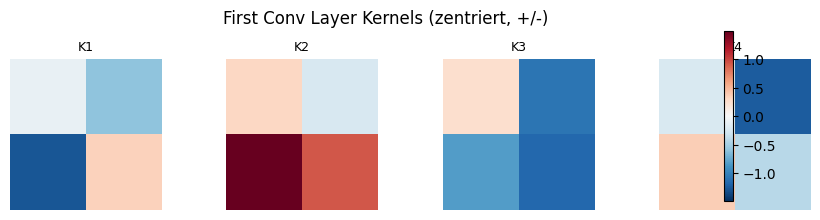

Epoch 1/1, TotalLoss: 1.3794, DataLoss: 1.3794, Accuracy: 0.6061, ||W_dense||=0.000, ||K_conv||=6.498
Nach Training: First Layer Kernels


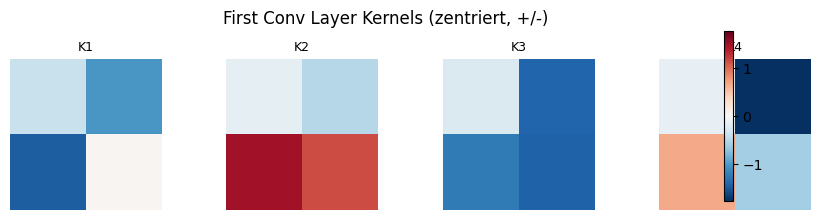

Nach Training: Feature Maps (gleiches Preprocessing wie im Training)


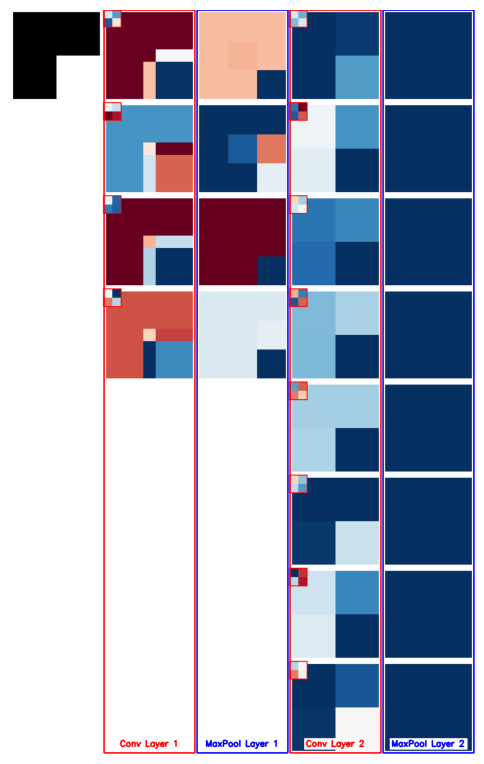

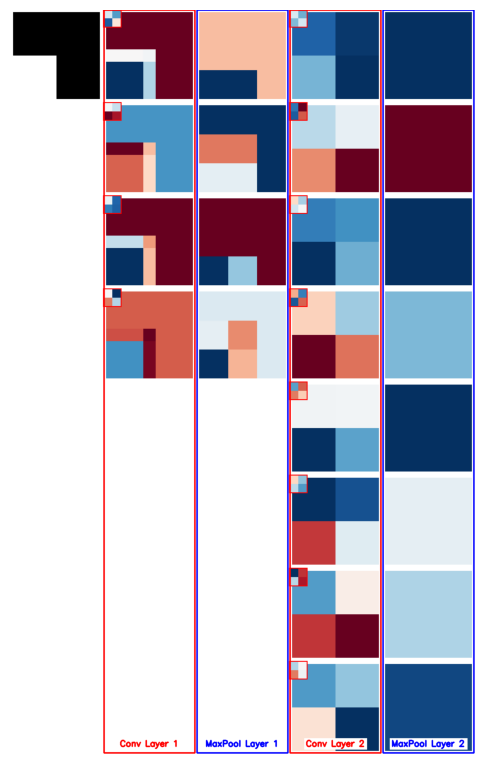

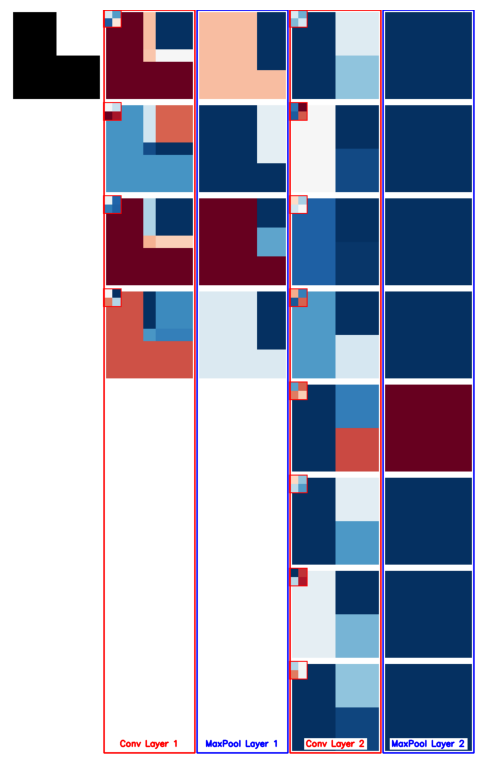

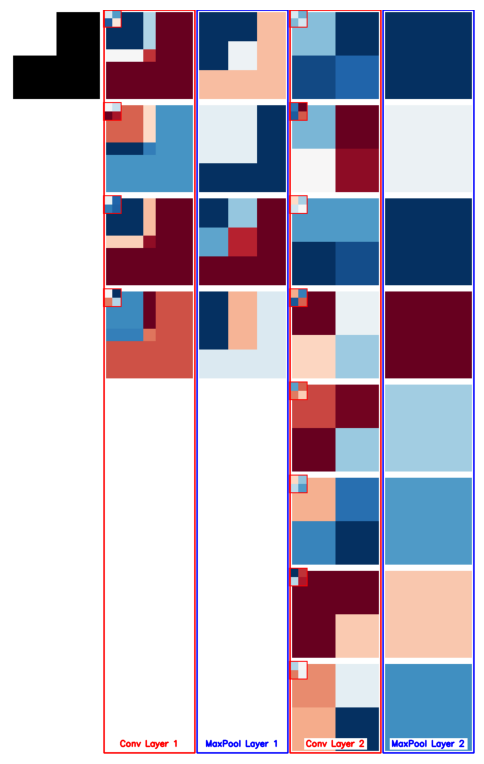

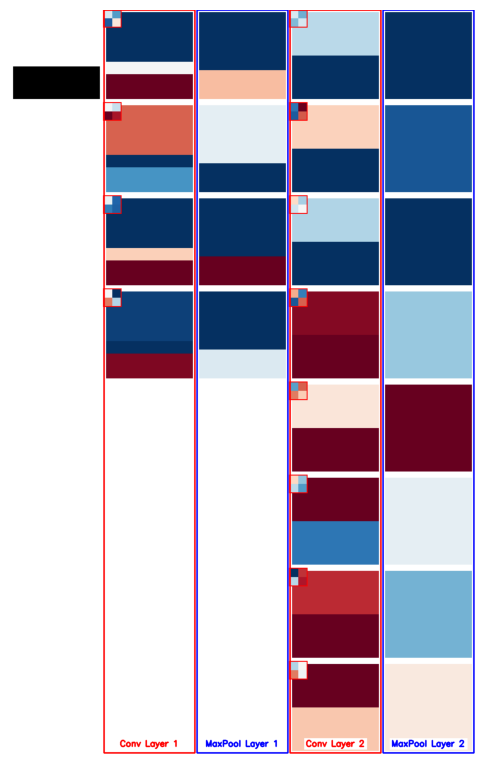

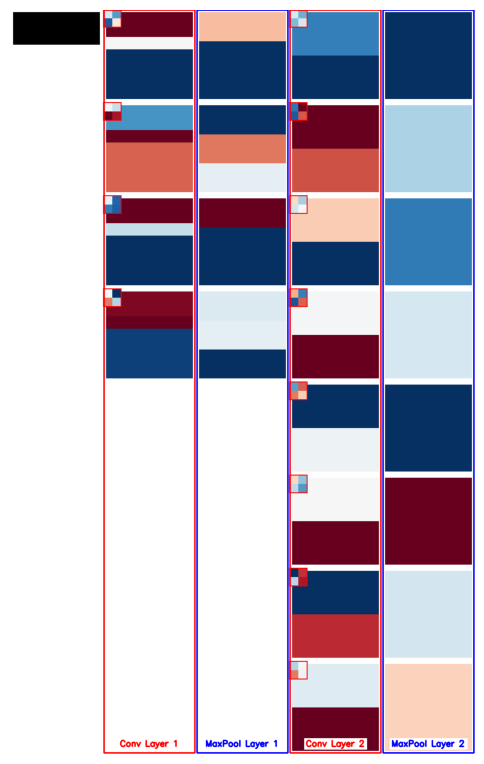

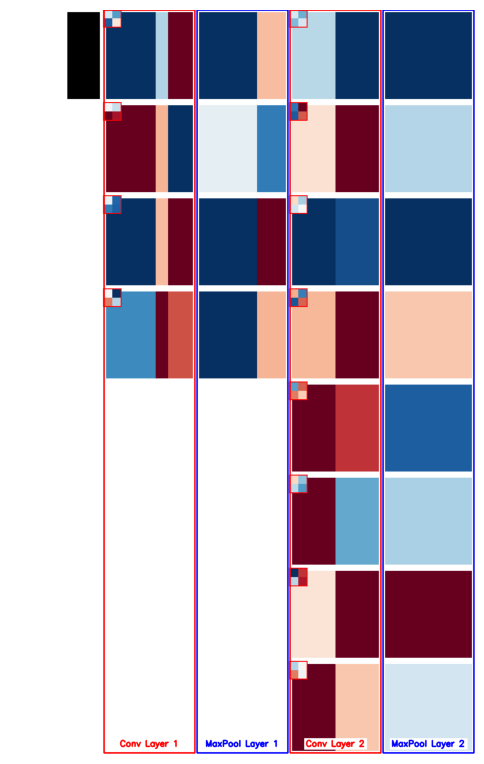

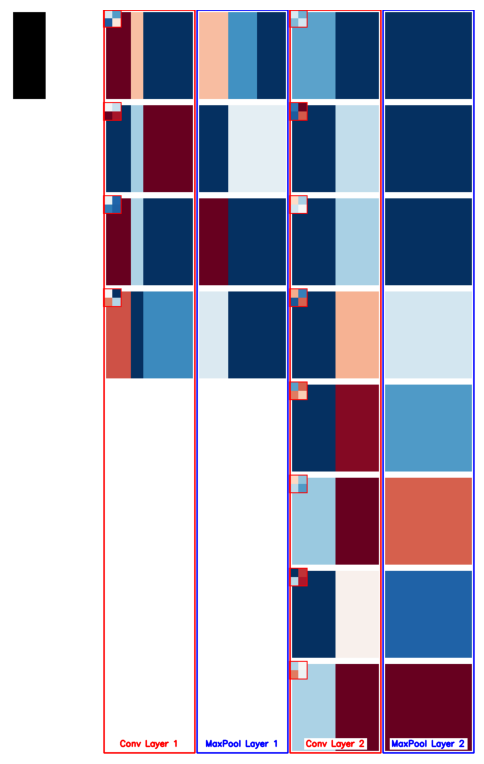

In [ ]:
from data import CornersAndEdgesDataset, one_hot_encode
from metrics import compute_accuracy, CrossEntropyLossWithSoftmax
from model import NeuralNetwork, ReLU, Flatten, DenseLayer
from tqdm import tqdm
import visualization as vis
import numpy as np

EPOCHS          = 12
BATCH_SIZE      = 32
LEARNING_RATE   = 0.01
WEIGHT_DECAY    = 1e-2   # L2-Regularisierung auf Dense-Gewichte
LR_CONV_FACTOR  = 2.5    # Conv-Updates relativ zu Dense verstärken
IMAGE_SIZE      = 8
VIS_KERNELS     = 8

# Demo-Modus für klar sichtbare Edge/Corner-Kernels im 1. Conv-Layer
ds = CornersAndEdgesDataset(
    num_samples=10000,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    augment=False,
    seed=42,
 )

# model = NeuralNetwork(modules=[
#     ConvLayer(in_channels=1, out_channels=8, kernel_size=2),
#     ReLU(),
#     MaxPool(kernel_size=4, stride=4),
#     Flatten(),
#     DenseLayer(in_features=8, out_features=len(ds.LABELS)),
# ])
model = NeuralNetwork(modules=[
    ConvLayer(in_channels=1, out_channels=4, kernel_size=2),
    ReLU(),
    MaxPool(kernel_size=2, stride=2),

    ConvLayer(in_channels=4, out_channels=8, kernel_size=2),
    ReLU(),
    MaxPool(kernel_size=2, stride=2),

    Flatten(),
    #DenseLayer(in_features=8, out_features=len(ds.LABELS)),
])

model.print_shapes(ds.images[0:1])

criterion = CrossEntropyLossWithSoftmax()
dense_layers = [m for m in model.modules if isinstance(m, DenseLayer)]
conv_layers = [m for m in model.modules if hasattr(m, "kernels")]

# Feste Referenz für den visuellen Vergleich
sample_image = ds.images[0, 0].copy()

print("Vor Training: First Layer Kernels")
vis.visualize_first_layer_kernels(model, max_kernels=VIS_KERNELS)

# Training
for epoch in range(EPOCHS):
    losses_total, losses_data, accs_train = [], [], []
    prog_train = tqdm(ds, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False)

    for X, Y in prog_train:
        Y = one_hot_encode(Y, num_classes=len(ds.LABELS))

        Y_hat = model.forward(X)
        data_loss = criterion.forward(Y_hat, Y)
        reg_loss = 0.5 * WEIGHT_DECAY * sum(np.sum(layer.weights ** 2) for layer in dense_layers)
        total_loss = data_loss + reg_loss
        acc = compute_accuracy(Y_hat, Y)

        losses_data.append(data_loss)
        losses_total.append(total_loss)
        accs_train.append(acc)

        # Backward mit Basis-Learning-Rate
        conv_kernels_before = [layer.kernels.copy() for layer in conv_layers]
        grad_outputs = criterion.backward()
        model.backward(grad_outputs * LEARNING_RATE)

        # Conv-Layer relativ stärker updaten
        if LR_CONV_FACTOR != 1.0:
            for layer, kernels_before in zip(conv_layers, conv_kernels_before):
                layer.kernels = kernels_before + LR_CONV_FACTOR * (layer.kernels - kernels_before)

        # Decoupled Weight Decay nur auf Dense-Layer
        for layer in dense_layers:
            layer.weights *= (1.0 - LEARNING_RATE * WEIGHT_DECAY)

        prog_train.set_description(
            f"Epoch {epoch+1}/{EPOCHS}, TotalLoss: {np.mean(losses_total):.4f}, DataLoss: {np.mean(losses_data):.4f}, Accuracy: {np.mean(accs_train):.4f}"
        )

    dense_norm = np.sqrt(sum(np.sum(layer.weights ** 2) for layer in dense_layers))
    conv_norm = np.sqrt(sum(np.sum(layer.kernels ** 2) for layer in conv_layers))

    print(
        f"Epoch {epoch+1}/{EPOCHS}, TotalLoss: {np.mean(losses_total):.4f}, DataLoss: {np.mean(losses_data):.4f}, "
        f"Accuracy: {np.mean(accs_train):.4f}, ||W_dense||={dense_norm:.3f}, ||K_conv||={conv_norm:.3f}"
    )

print("Nach Training: First Layer Kernels")
vis.visualize_first_layer_kernels(model, max_kernels=VIS_KERNELS)

print("Nach Training: Feature Maps (gleiches Preprocessing wie im Training)")
#vis.visualize_features(sample_image, model, n_kernels=VIS_KERNELS, zscore_input=False)
for image in ds.images:
    vis.visualize_features(image[0], model, n_kernels=VIS_KERNELS, zscore_input=False)

#print("Optional: Für Vergleich mit z-score Input")
# vis.visualize_features(sample_image, model, n_kernels=VIS_KERNELS, zscore_input=True)